# Regular TransE

In [1]:
import numpy as np
import pandas as pd
import torch
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pickle
import torch.nn as nn
import torch.optim as optim
import random
from torch.utils.data import Dataset, DataLoader
import re

Add the location of your preprocessed files below

In [2]:
csv_file = '../preprocess/'

Import CPE

In [3]:
df_cpe = pd.read_csv(csv_file + "csv_file/2021aug/cpe_ignore_version.csv", usecols=['part','vendor',
                'product', 'target_sw','target_hw','name','size']).sort_values(
                'size', ascending=False)

Import CVE

In [4]:
df_cve = pd.read_csv(csv_file + "csv_file/2021aug/cve/cve-2002.csv")
df_cve = df_cve.astype('object').fillna('*')
df_list = [df_cve]
for i in range(2003, 2022):
    filename = f'{csv_file}csv_file/2021aug/cve/cve-{i}.csv'
    df_temp = pd.read_csv(filename)
    df_temp = df_temp.astype('object').fillna('*')
    df_list.append(df_temp)
df_cve = pd.concat(df_list, ignore_index=True)


Import CWE

In [5]:
df_cwe = pd.read_csv(csv_file + "csv_file/2021aug/cwe.csv")
df_cwe.fillna('*', inplace=True)

df_cwe_cate = pd.read_csv(csv_file + "csv_file/2021aug/cwe_category.csv")
df_cwe_view = pd.read_csv(csv_file + "csv_file/2021aug/cwe_view.csv")
df_cwe_cate.fillna('*', inplace=True)
df_cwe_view.fillna('*', inplace=True)

,ID,Name,Type,Status,Has_Member
0,CWE-1000,"""Research Concepts""",Graph,Draft,CWE-284;CWE-435;CWE-664;CWE-682;CWE-691;CWE-69...
1,CWE-1003,"""Weaknesses for Simplified Mapping of Publishe...",Graph,Incomplete,CWE-20;CWE-74;CWE-116;CWE-119;CWE-200;CWE-269;...
2,CWE-1008,"""Architectural Concepts""",Graph,Incomplete,CWE-1009;CWE-1010;CWE-1011;CWE-1012;CWE-1013;C...
3,CWE-1026,"""Weaknesses in OWASP Top Ten (2017)""",Graph,Incomplete,CWE-1027;CWE-1028;CWE-1029;CWE-1030;CWE-1031;C...
4,CWE-1040,"""Quality Weaknesses with Indirect Security Imp...",Implicit,Incomplete,*
5,CWE-1081,"""Entries with Maintenance Notes""",Implicit,Draft,*
6,CWE-1128,"""CISQ Quality Measures (2016)""",Graph,Incomplete,CWE-1129;CWE-1130;CWE-1131;CWE-1132
7,CWE-1133,"""Weaknesses Addressed by the SEI CERT Oracle C...",Graph,Stable,CWE-1134;CWE-1135;CWE-1136;CWE-1137;CWE-1138;C...
8,CWE-1154,"""Weaknesses Addressed by the SEI CERT C Coding...",Graph,Stable,CWE-1155;CWE-1156;CWE-1157;CWE-1158;CWE-1159;C...
9,CWE-1178,"""Weaknesses Addressed by the SEI CERT Perl Cod...",Graph,Stable,CWE-1179;CWE-1180;CWE-1181;CWE-1182;CWE-1183;C...


In [6]:
print("The size of df_cpe, df_cve, df_cwe are:", df_cpe.shape[0], df_cve.shape[0], df_cwe.shape[0])

The size of df_cpe, df_cve, df_cwe are: 68338 167542 918


In [7]:
cwe_disc = ["CWE-119", "CWE-20", "CWE-200", "CWE-269", "CWE-287",
            "CWE-311", "CWE-330", "CWE-345", "CWE-400", "CWE-610",
            "CWE-662", "CWE-665", "CWE-668", "CWE-682", "CWE-697",
            "CWE-74", "CWE-755", "CWE-834"]
cwe_prohibited = df_cwe_cate["ID"].tolist() + df_cwe_view["ID"].tolist()

In [8]:
cwe_list = []

kg_cwe = []

for i, r in df_cwe.iterrows():
    cweid = r['ID']


    cwe_list.append(cweid)

    if (r['Related_Weakness'] != '*'):
        relatedlist = r['Related_Weakness'].split(';')
        for re in relatedlist:
            relation, other = re.split(':')
            other = 'CWE-' + other
            kg_cwe.append(([cweid, relation, other]))

    if (r['Language'] != '*'):
        langlist = r['Language'].split(';')
        for l in langlist:
            if (l != 'Language-Independent'):
                kg_cwe.append(([cweid, 'Language', l]))

    if (r['Technology'] != '*'):
        techlist = r['Technology'].split(';')
        for t in techlist:
            if (t != 'Technology-Independent'):
                kg_cwe.append(([cweid, 'Technology', t]))

    if (r['Likelihood_Of_Exploit'] != '*'):
        kg_cwe.append(([cweid, 'LikelihoodOfExploit', \
                        r['Likelihood_Of_Exploit']]))

    if (r['Consequence'] != '*'):
        conseqlist = r['Consequence'].split(';')
        for c in conseqlist:
            if (c != 'Other'):
                kg_cwe.append(([cweid, 'Consequence', c]))

In [9]:
kg_cate = []
kg_view = []

for i, r in df_cwe_cate.iterrows():
    cid = r['ID']

    if (r['Has_Member'] != '*'):
        memlist = r['Has_Member'].split(';')
        for m in memlist:
            kg_cate.append(([cid, 'Has_Member', m]))

for i, r in df_cwe_view.iterrows():
    vid = r['ID']

    if (r['Has_Member'] != '*'):
        memlist = r['Has_Member'].split(';')
        for m in memlist:
            kg_view.append(([vid, 'Has_Member', m]))

In [10]:
cpe_candidate_list = df_cpe['name'].values.tolist()

In [11]:
cve_candidate_list = []
connected_cvelist = []

kg_cve = []
kg_cpe2cve = []
kg_cve2cwe = []

connected_cpelist = []

for i, r in tqdm(df_cve.iterrows(), total = len(df_cve)):
    cveid = r['ID']
    cve_candidate_list.append(cveid)
    is_connected = 0

    if (r['MatchingCPE'] != '*'):
        cpes_related = r['MatchingCPE'].split(';')
        plist = []
        for p in cpes_related:

            p = p.replace(r'\,', r'\.')
            p = p.replace(r'\:', r'\;')
            p = p.replace('"', "'")

            p_detail = p.split(':')
            pp = ':'.join(['cpe']+p_detail[2:5]+p_detail[10:12])
            if (pp not in plist)  and (pp in cpe_candidate_list):
                matchcpe = [pp, 'MatchingCVE', cveid]
                kg_cpe2cve.append((matchcpe))
                is_connected += 1

            if pp not in connected_cpelist and (pp in cpe_candidate_list):
                connected_cpelist.append(pp)

            plist.append(pp)

    if (r['MatchingCWE'] != '*' and r['MatchingCWE'] != 'NVD-CWE-Other' and r['MatchingCWE'] != 'NVD-CWE-noinfo'):
        cwelist = r['MatchingCWE'].split(';')
        for w in cwelist:
            if (w != 'NVD-CWE-noinfo') and (w in cwe_list or w in df_cwe_cate['ID'].values.tolist() or w in df_cwe_view['ID'].values.tolist()):
                if w == 'CWE-17':
                    print(cveid, w)
                # skip over CVE that are mapped to a prohibited or discouraged CWE
                if w not in cwe_disc + cwe_prohibited:
                    matchcwe = [cveid, 'MatchingCWE', w]
                    kg_cve2cwe.append((matchcwe))
                    is_connected += 1

    if is_connected:
        connected_cvelist.append(cveid)
        is_connected = 0

kg_cve = kg_cpe2cve + kg_cve2cwe

  0%|          | 0/167542 [00:00<?, ?it/s]

In [12]:
with open('./saved_retrain_0/cpelist_connected.txt', 'w') as f:
    for items in connected_cpelist:
        f.write('%s\n' %items)
    print("File written successfully")
f.close()

File written successfully


In [13]:
with open('./saved_retrain_0/cvelist_connected.txt', 'w') as f:
    for items in connected_cvelist:
        f.write('%s\n' %items)
    print("File written successfully")
f.close()

File written successfully


In [14]:
f = open('./saved_retrain_0/cpelist_connected.txt', 'r')
connected_cpelist = f.read().splitlines()
f.close()

In [15]:
f = open('./saved_retrain_0/cvelist_connected.txt', 'r')
connected_cvelist = f.read().splitlines()
f.close()

In [16]:
cpe2cve_df = pd.DataFrame(kg_cpe2cve, columns=["subject", "predicate", "object"])
cpe2cve_df.to_csv('./saved_retrain_0/cpe2cve-aug2021.csv', index=False)

cve2cwe_df = pd.DataFrame(kg_cve2cwe, columns=["subject", "predicate", "object"])
cve2cwe_df.to_csv('./saved_retrain_0/cve2cwe-aug2021.csv', index=False)

In [17]:
# Load data
kg_cpe2cve_df = pd.read_csv("./saved_retrain_0/cpe2cve-aug2021.csv")
kg_cve2cwe_df = pd.read_csv("./saved_retrain_0/cve2cwe-aug2021.csv")

# Convert to list of triples using .values.tolist()
kg_cpe2cve = kg_cpe2cve_df[['subject', 'predicate', 'object']].values.tolist()
kg_cve2cwe = kg_cve2cwe_df[['subject', 'predicate', 'object']].values.tolist()

# Combine the two
kg_cve = kg_cpe2cve + kg_cve2cwe

In [18]:
kg_cpe = []

for i, r in df_cpe.iterrows():
    cpeid = r['name']

    if cpeid in connected_cpelist:
        kg_cpe.append([cpeid, "Part", r['part']])
        kg_cpe.append([cpeid, "Vendor", r['vendor']])
        kg_cpe.append([cpeid, "Product", r['product']])
        if (r['target_sw'] != "*"):
            kg_cpe.append([cpeid, "Target_sw", r['target_sw']])
        if (r['target_hw'] != "*"):
            kg_cpe.append([cpeid, "Target_hw", r['target_hw']])

In [19]:
triples = kg_cpe + kg_cve + kg_cwe + kg_cate + kg_view

In [20]:
triples_df = pd.DataFrame(triples, columns=["subject", "predicate", "object"])
triples_df.to_csv('./saved_retrain_0/kg_demo_aug2021.csv', index=False)

### Model Initialization

In [21]:
triples_df = pd.read_csv("./saved_retrain_0/kg_demo_aug2021.csv", usecols=["subject", "predicate", "object"])
triples = triples_df[['subject', 'predicate', 'object']].values.tolist()

In [22]:
triples_df.shape

(373604, 3)

Below we produce dictionaries for entity (head or tail) and relation conversions to a number (ID). For example, CWE-200 could have an ID of 2587. These are necessary when training the model.

In [23]:
entities = set()
relations = set()
for triple in triples:
    h, r, t = triple
    entities.add(h)
    entities.add(t)
    relations.add(r)

print(f"Number of entities: {len(entities)}")
print(f"Number of relations: {len(relations)}")
num_entities = len(entities)
num_relations = len(relations)

# must be sorted to produce identical remappings if code block is run again
entity2id = {entity: idx for idx, entity in sorted(enumerate(entities))}
id2entity = {idx: entity for entity, idx in entity2id.items()}

relation2id = {relation: idx for idx, relation in sorted(enumerate(relations))}
id2relation = {idx: relation for relation, idx in relation2id.items()}

triples_id = []
for h, r, t in triples:
    triples_id.append([entity2id[h], relation2id[r], entity2id[t]])
triples_id = np.array(triples_id)


Number of entities: 192835
Number of relations: 18


The same ID - entity/relation mappings must be used for model training and evaluation to see accurate and consistent results. As a result, we save the ID conversions below to load them later.

In [24]:
with open("id_conversions_retrain_0/entity2id.pkl", "wb") as f:
    pickle.dump(entity2id, f)

with open("id_conversions_retrain_0/id2entity.pkl", "wb") as f:
    pickle.dump(id2entity, f)

with open("id_conversions_retrain_0/relation2id.pkl", "wb") as f:
    pickle.dump(relation2id, f)

with open("id_conversions_retrain_0/id2relation.pkl", "wb") as f:
    pickle.dump(id2relation, f)

np.save("id_conversions_retrain_0/triples_id.npy", triples_id)


In [25]:
class TransE(nn.Module):
    def __init__(self, num_entities, num_relations, embedding_dim):
        super(TransE, self).__init__()
        self.num_entities = num_entities
        self.num_relations = num_relations
        self.embedding_dim = embedding_dim

        self.entity_embeddings = nn.Embedding(num_entities, embedding_dim)
        self.relation_embeddings = nn.Embedding(num_relations, embedding_dim)
 

        nn.init.xavier_uniform_(self.entity_embeddings.weight.data)
        nn.init.xavier_uniform_(self.relation_embeddings.weight.data)

    def forward(self, pos_triples, neg_triples):
        pos_score = self.score_triples(pos_triples)

        # reshaping b/c >1 neg triple per pos triple 
        # (batch_size, num_neg, 3) -> (batch_size * num_neg, 3)
        batch_size, num_neg, _ = neg_triples.shape
        neg_triples = neg_triples.view(-1, 3)

        neg_score = self.score_triples(neg_triples)
        return pos_score, neg_score

    def predict(self, triples):
        return self.score_triples(triples)

    # transe scoring - higher score = better fit.
    # this can be changed for distmult (h*r*t) or complex
    def score_triples(self, triples):
        h = self.entity_embeddings(triples[:, 0])
        r = self.relation_embeddings(triples[:, 1])
        t = self.entity_embeddings(triples[:, 2])

        # ampligraph defaults to l1 norm
        score = -torch.norm(h + r - t, p=1, dim=1)
        return score

The below code is an implementation of the Multiclass Negative Log Likelihood that we use in AmpliGraph 1.4.0. The loss function was implemented by referring to AmpliGraph's [source code](https://github.com/Accenture/AmpliGraph/blob/develop/ampligraph/latent_features/loss_functions.py). 

In [26]:
#ensure against integer overflow
def clip_before_exp(x):
    return torch.clamp(x, max=75.0, min=-75.0)


def loss_function(pos_score, neg_score, model, lambda_reg=1e-5):
    # Shape assumptions:
    # pos_score: (batch_size,) or (batch_size, 1)
    # neg_score: (batch_size, num_neg)

    pos_score = pos_score.view(-1, 1)  # (batch_size, 1)
    neg_score = neg_score.view(pos_score.size(0), -1)  # (batch_size, num_neg)

    # Clip before exp like AmpliGraph
    pos_score_clipped = clip_before_exp(pos_score)
    neg_score_clipped = clip_before_exp(neg_score)

    pos_exp = torch.exp(pos_score_clipped)
    neg_exp_sum = torch.sum(torch.exp(neg_score_clipped), dim=1, keepdim=True)

    softmax_score = pos_exp / (pos_exp + neg_exp_sum + 1e-10)
    loss = -torch.log(softmax_score + 1e-10) 
    loss = loss.sum()
    #regularizer
    l3_loss = sum(torch.sum(torch.abs(param) ** 3) for param in [model.entity_embeddings.weight, model.relation_embeddings.weight])
    return loss + lambda_reg * l3_loss

In [27]:
class KGDataset(Dataset):
    def __init__(self, triples):
        self.triples = triples

    def __len__(self):
        return len(self.triples)

    def __getitem__(self, idx):
        return self.triples[idx]

In the AmpliGraph implementation of the model, we generate negative triples for each positive triple.
```python
model_transe = TransE(batches_count=50,
    epochs=300,
    k=100,
    eta=20,
    embedding_model_params={'corrupt_sides': ['s,o'], 'negative_corruption_entities': 'batch'},
    optimizer='adam',
    optimizer_params={'lr':1e-4},
    loss='multiclass_nll',
    regularizer="LP",
    regularizer_params={'p':3, 'lambda':1e-5},
    seed=0,
    verbose=True)
```
The ```embedding_model_params```argument specifies this. We corrupt either the subject or object and we produce these corruptions by selecting any of the entities in the same batch, which is specified by the ```negative_corruption_entities``` key. The following function mimics this behavior by first receiving all entities in the specific batch and producing ```eta=20``` negative triples for each positive triple.

In [28]:
def generate_batch_negatives(pos_triples, entity_ids, eta=20, corrupt_head_prob=0.5):
    batch_size = pos_triples.shape[0]
    device = pos_triples.device

    # randomly decide whether to corrupt head or tail 1-head, 0-tail
    # batch_size*eta for each neg triple per pos triple in batch
    corrupt_heads = torch.rand(batch_size * eta, device=device) < corrupt_head_prob

    # Repeat positive triples eta times
    pos_repeated = pos_triples.repeat_interleave(eta, dim=0)

    # batch entities to choose from when corrupting
    entity_ids = torch.tensor(entity_ids, device=device)
    # get random entities to use when corrupting h or t
    corrupt_ents = entity_ids[torch.randint(0, len(entity_ids), (batch_size * eta,), device=device)]

    # Clone and corrupt
    neg_triples = pos_repeated.clone()
    neg_triples[corrupt_heads, 0] = corrupt_ents[corrupt_heads]
    neg_triples[~corrupt_heads, 2] = corrupt_ents[~corrupt_heads]

    # reshape back to (batch_size, eta, 3)
    return neg_triples.view(batch_size, eta, 3)


### Model Training

All the hyperparameters below are similar to the AmpliGraph implementation except for the number of epochs. I used the validation set to determine when to stop training but it usually takes less than 100 epochs.

In [29]:
#reproducible performance
num = 0
random.seed(num)
np.random.seed(num)
torch.manual_seed(num)
torch.cuda.manual_seed(num)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [30]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

embedding_dim = 100
lambda_reg = 1e-5
num_epochs = 75
batches_count = 50
eta = 20  # number of negative triples per positive triple
learning_rate = 1e-4

batch_size = int(len(triples_id)/batches_count)
train_dataset = KGDataset(triples_id)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
model = TransE(
    num_entities=len(entity2id),
    num_relations=len(relation2id),
    embedding_dim=embedding_dim
).to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in tqdm(range(num_epochs)):
    model.train()
    total_loss = 0
    for pos_triples in train_loader:
        pos_triples = pos_triples.long().to(device)

        # get unique entities (head and tail) in the current batch
        batch_entities = pos_triples[:, [0, 2]].unique().tolist()

        # generate negatives from batch entities only
        neg_triples = generate_batch_negatives(pos_triples, batch_entities, eta=eta)
        neg_triples = neg_triples.long().to(device)

        optimizer.zero_grad()
        pos_score, neg_score = model(pos_triples, neg_triples)
        loss = loss_function(pos_score, neg_score, model, lambda_reg)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Using device: cuda


  0%|          | 0/75 [00:00<?, ?it/s]

Epoch 1/75, Loss: 21711.8074
Epoch 2/75, Loss: 20546.9274
Epoch 3/75, Loss: 19657.0252
Epoch 4/75, Loss: 18952.0992
Epoch 5/75, Loss: 18365.3692
Epoch 6/75, Loss: 17873.9709
Epoch 7/75, Loss: 17445.1750
Epoch 8/75, Loss: 17063.9281
Epoch 9/75, Loss: 16712.0750
Epoch 10/75, Loss: 16386.7480
Epoch 11/75, Loss: 16079.9615
Epoch 12/75, Loss: 15789.2696
Epoch 13/75, Loss: 15507.3980
Epoch 14/75, Loss: 15245.7352
Epoch 15/75, Loss: 14980.5486
Epoch 16/75, Loss: 14724.5495
Epoch 17/75, Loss: 14483.1135
Epoch 18/75, Loss: 14242.3811
Epoch 19/75, Loss: 14000.0968
Epoch 20/75, Loss: 13766.3944
Epoch 21/75, Loss: 13535.2061
Epoch 22/75, Loss: 13316.0145
Epoch 23/75, Loss: 13098.5482
Epoch 24/75, Loss: 12878.7504
Epoch 25/75, Loss: 12672.9536
Epoch 26/75, Loss: 12468.8720
Epoch 27/75, Loss: 12266.4134
Epoch 28/75, Loss: 12066.4427
Epoch 29/75, Loss: 11870.7719
Epoch 30/75, Loss: 11680.7534
Epoch 31/75, Loss: 11504.4480
Epoch 32/75, Loss: 11329.8069
Epoch 33/75, Loss: 11160.8521
Epoch 34/75, Loss: 

Save Model

In [31]:
torch.save(model.state_dict(), "models_trained_scc/transe_model_nll_retrain_0.pt")
model.eval()

TransE(
  (entity_embeddings): Embedding(192835, 100)
  (relation_embeddings): Embedding(18, 100)
)

Load Model and ID Conversions for evaluation below

In [32]:
with open("id_conversions_retrain_0/entity2id.pkl", "rb") as f:
    entity2id = pickle.load(f)

with open("id_conversions_retrain_0/id2entity.pkl", "rb") as f:
    id2entity = pickle.load(f)

with open("id_conversions_retrain_0/relation2id.pkl", "rb") as f:
    relation2id = pickle.load(f)

with open("id_conversions_retrain_0/id2relation.pkl", "rb") as f:
    id2relation = pickle.load(f)

triples_id = np.load("id_conversions_retrain_0/triples_id.npy")

In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransE(
    num_entities=len(entity2id),
    num_relations=len(relation2id),
    embedding_dim=100
)

# Load the saved weights
model.load_state_dict(torch.load("models_trained_scc/transe_model_nll_retrain_0.pt", map_location=device))
model.to(device)

# remove this if you just want to continue training
model.eval()  # set to evaluation mode


TransE(
  (entity_embeddings): Embedding(192835, 100)
  (relation_embeddings): Embedding(18, 100)
)

### Open World Evaluation of Model

In [34]:
kg_cpe2cve_nov2022_df = pd.read_csv("./saved/cpe2cve-nov2022.csv")
kg_cpe2cve_nov2022 = kg_cpe2cve_nov2022_df[['subject', 'predicate', 'object']].values.tolist()

kg_cve2cwe_2022_df = pd.read_csv("./saved/cve2cwe-nov2022.csv")
kg_cve2cwe_nov2022 = kg_cve2cwe_2022_df[['subject', 'predicate', 'object']].values.tolist()

In [35]:
new_cve2cwe = []

li1 = []
li2 = []
for l in kg_cve2cwe_nov2022:
    li1.append(l[0]+','+l[1]+','+l[2])
for l in kg_cve2cwe:
    li2.append(l[0]+','+l[1]+','+l[2])

new_tmp = list(set(li1) - set(li2))
for s in new_tmp:
    new_cve2cwe.append(s.split(','))

new_cve2cwe_df = pd.DataFrame(new_cve2cwe, columns=["subject", "predicate", "object"]).sort_values(by=['subject'], ascending=True).reset_index(drop=True)

In [36]:
# keep only the relations between existing nodes
new_test_cve2cwe = []

kg_cve2cwe_df = pd.DataFrame(kg_cve2cwe, columns=["subject", "predicate", "object"])
for i, r in new_cve2cwe_df.iterrows():
    if r['subject'] in connected_cvelist:
        new_test_cve2cwe.append(r)

In [37]:
# save new_test_cve2cwe locally
new_test_cve2cwe_df = pd.DataFrame(new_test_cve2cwe, columns=["subject", "predicate", "object"])
new_test_cve2cwe_df.to_csv('./saved/new_test_cve2cwe_aug2021_nov2022.csv', index=False)

In [38]:
new_cpe2cve = []

li1 = []
li2 = []
for l in kg_cpe2cve_nov2022:
    li1.append(l[0]+','+l[1]+','+l[2])
for l in kg_cpe2cve:
    li2.append(l[0]+','+l[1]+','+l[2])

new_tmp = list(set(li1) - set(li2))
for s in new_tmp:
    new_cpe2cve.append(s.split(','))

new_cpe2cve_df = pd.DataFrame(new_cpe2cve, columns=["subject", "predicate", "object"]).sort_values(by=['subject'], ascending=True).reset_index(drop=True)

In [39]:
# keep only the relations between existing nodes
new_test_cpe2cve = []

kg_cpe2cve_df = pd.DataFrame(kg_cpe2cve, columns=["subject", "predicate", "object"])
for i, r in new_cpe2cve_df.iterrows():
    if r['subject'] in connected_cpelist:
        if r['object'] in connected_cvelist:
            new_test_cpe2cve.append(r)

In [40]:
# save new_test_cpe2cve locally
new_test_cpe2cve_df = pd.DataFrame(new_test_cpe2cve, columns=["subject", "predicate", "object"])
new_test_cpe2cve_df.to_csv('./saved/new_test_cpe2cve_aug2021_nov2022.csv', index=False)

In [41]:
# Load new_test_cve2cwe
new_test_cve2cwe_df = pd.read_csv("./saved/new_test_cve2cwe_aug2021_nov2022.csv")
new_test_cve2cwe = new_test_cve2cwe_df[['subject', 'predicate', 'object']].values.tolist()

# Load new_test_cpe2cve
new_test_cpe2cve_df = pd.read_csv("./saved/new_test_cpe2cve_aug2021_nov2022.csv")
new_test_cpe2cve = new_test_cpe2cve_df[['subject', 'predicate', 'object']].values.tolist()

In [42]:
cwe_list = df_cwe['ID'].values.tolist()

The following evaluation is for new CVE-CWE and CPE-CVE mappings (open-world) specifically. To evaluate CVE-CWE mappings, we replace the CWE with all other CWEs (which form negative triples) and see if the one that is the true mapping ranks higher than all the negative triples. Similary, for CPE-CVE mappings, we replace the CPE with all other CPEs. The ```known_triples_set``` argument makes sure that the potential "corrupted triples" are not also positive triples. If they are, it ignores that that corrupted triple. It filters out any positive triples from the set of corrupted triples if that happens.

In [43]:
#used for evaluation
def mr_score(ranks):
    return np.mean(ranks)


def mrr_score(ranks):
    return np.mean([1.0 / rank for rank in ranks])


def hits_at_n(ranks, n):
    return np.mean([rank <= n for rank in ranks])

---------------CPE-CVE-----------------


  0%|          | 0/12120 [00:00<?, ?it/s]

Mean Rank: 938.6624587458746
Hits@1: 0.1
Hits@3: 0.1820957095709571
Hits@10: 0.30767326732673267
Hits@20: 0.40825082508250826
MRR: 0.16970747178870402


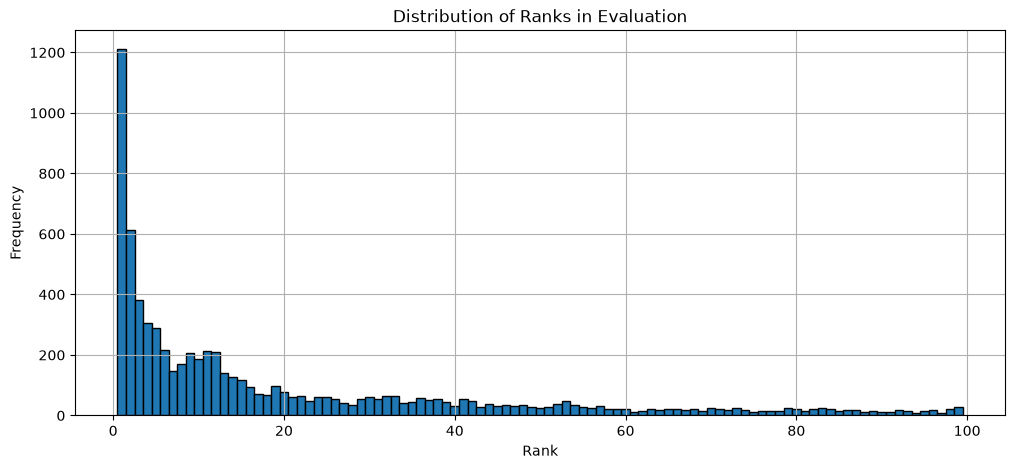

---------------CVE-CWE-----------------


  0%|          | 0/24571 [00:00<?, ?it/s]

Mean Rank: 209.56880061861543
Hits@1: 0.0034186642790281227
Hits@3: 0.008221073623377153
Hits@10: 0.020430588905620446
Hits@20: 0.031622644581010134
MRR: 0.01353823823329395


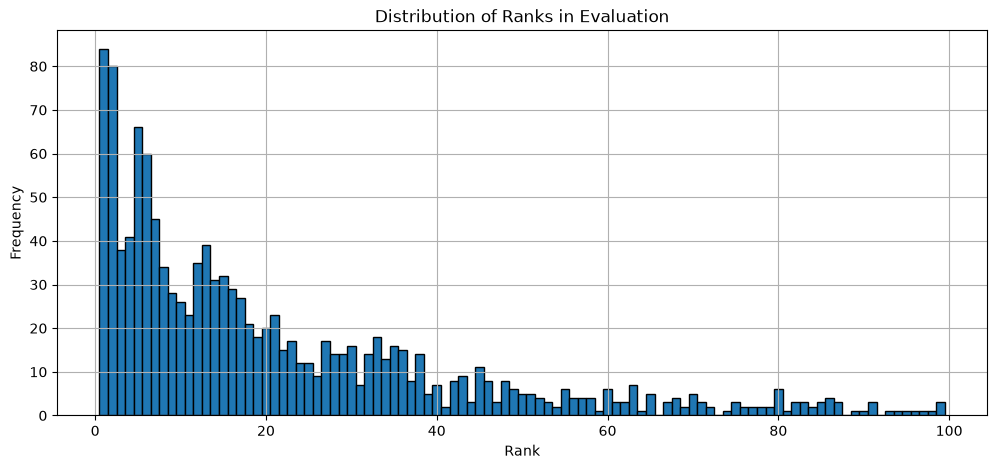

In [44]:
def evaluate_model(model, test_triples, all_entities, known_triples_set, corrupt_side='tail'):
    model.eval()
    ranks = []
    with torch.no_grad():
        for idx in tqdm(range(len(test_triples))):
            h, r, t = test_triples[idx]
            h_id = torch.tensor([h], device=device).long()
            r_id = torch.tensor([r], device=device).long()
            t_id = torch.tensor([t], device=device).long()

            corrupted_entities = []
            for e in all_entities:
                if corrupt_side == 'tail':
                    if e != t:
                        candidate = (h, r, e)
                elif corrupt_side == 'head':  # corrupt head
                    if e != h:
                        candidate = (e, r, t)
                else:
                    continue
                if candidate not in known_triples_set:
                    corrupted_entities.append(e)

            corrupted_entities = torch.tensor(corrupted_entities, device=device).long()

            if corrupt_side == 'tail':
                h_ids = h_id.repeat(len(corrupted_entities))
                r_ids = r_id.repeat(len(corrupted_entities))
                t_ids = corrupted_entities
                true_triple = torch.tensor([[h, r, t]], device=device).long()
            else:
                h_ids = corrupted_entities
                r_ids = r_id.repeat(len(corrupted_entities))
                t_ids = t_id.repeat(len(corrupted_entities))
                true_triple = torch.tensor([[h, r, t]], device=device).long()

            corrupted_triples = torch.stack((h_ids, r_ids, t_ids), dim=1)
            corrupted_scores = model.predict(corrupted_triples)
            true_score = model.predict(true_triple)

            all_scores = torch.cat([true_score, corrupted_scores])
            sorted_scores, indices = torch.sort(all_scores, descending=True)
            rank = (indices == 0).nonzero(as_tuple=True)[0].item() + 1
            ranks.append(rank)
    
    print(f"Mean Rank: {mr_score(ranks)}")
    for k in [1, 3, 10, 20]:
        print(f"Hits@{k}: {hits_at_n(ranks, k)}")
    print(f"MRR: {mrr_score(ranks)}")
    plt.figure(figsize=(12, 5))
    n, bins, patches = plt.hist(ranks, bins=range(1, 101), edgecolor='black', align='left')
    plt.xlabel('Rank')
    plt.ylabel('Frequency')
    plt.title('Distribution of Ranks in Evaluation')
    
    plt.grid(True)
    plt.show()
    return ranks

print("---------------CPE-CVE-----------------")
test_triples = []
for h, r, t in new_test_cpe2cve:
    test_triples.append([entity2id[h], relation2id[r], entity2id[t]])

tails = [entity2id[e] for e in connected_cpelist]
num_test_triples = len(test_triples)
known_triples_set = set(tuple([h, r, t]) for h, r, t in np.vstack((triples_id, test_triples)))
ranks = evaluate_model(model, test_triples[:num_test_triples], tails, known_triples_set, corrupt_side='head')

print("---------------CVE-CWE-----------------")
test_triples = []
for h, r, t in new_test_cve2cwe:
    test_triples.append([entity2id[h], relation2id[r], entity2id[t]])

tails = [entity2id[e] for e in cwe_list]
num_test_triples = len(test_triples)
known_triples_set = set(tuple([h, r, t]) for h, r, t in np.vstack((triples_id, test_triples)))
ranks = evaluate_model(model, test_triples[:num_test_triples], tails, known_triples_set, corrupt_side='tail')

## Closed World Evaluation

In [45]:
def train_test_split_no_unseen(triples, test_size=10000, seed=0):
    """
    Split triples into train and test sets while ensuring that every
    entity and relation appearing in the test set also appears in train.
    """

    rng = np.random.default_rng(seed)

    triples = np.asarray(triples)

    if test_size >= len(triples):
        raise ValueError(
            "test_size must be smaller than the total number of triples."
        )

    # ---------------------------------------------------------
    # Count how many times each entity/relation occurs
    # ---------------------------------------------------------

    subject_counts = {}
    object_counts = {}
    relation_counts = {}

    for h, r, t in triples:

        subject_counts[h] = subject_counts.get(h, 0) + 1
        object_counts[t] = object_counts.get(t, 0) + 1
        relation_counts[r] = relation_counts.get(r, 0) + 1

    # ---------------------------------------------------------
    # Randomize triple order
    # ---------------------------------------------------------

    indices = np.arange(len(triples))
    rng.shuffle(indices)

    test_indices = []
    train_mask = np.ones(len(triples), dtype=bool)

    # ---------------------------------------------------------
    # Select test triples
    #
    # A triple can go into the test set only if removing it
    # does NOT make its subject, relation, or object disappear
    # from the training set.
    # ---------------------------------------------------------

    for idx in indices:

        if len(test_indices) >= test_size:
            break

        h, r, t = triples[idx]

        # If this is the last occurrence of ANY component,
        # removing this triple would create an unseen entity
        # or relation in the test set.
        if subject_counts[h] <= 1:
            continue

        if object_counts[t] <= 1:
            continue

        if relation_counts[r] <= 1:
            continue

        # Accept this triple for the test set
        test_indices.append(idx)
        train_mask[idx] = False

        # Update counts because this triple is no longer
        # part of the training set.
        subject_counts[h] -= 1
        object_counts[t] -= 1
        relation_counts[r] -= 1


    X_valid = triples[test_indices]
    X_train = triples[train_mask]

    return X_train, X_valid

In [46]:
X_train, X_valid = train_test_split_no_unseen(
    np.array(triples),
    test_size=10000,
    seed=0
)

In [47]:
print("Train set size:", X_train.shape)
print("Test set size:", X_valid.shape)

Train set size: (363604, 3)
Test set size: (10000, 3)


In [48]:
# Entities and relations in training set
train_entities = set(X_train[:, 0]) | set(X_train[:, 2])
train_relations = set(X_train[:, 1])

# Entities and relations in test set
test_entities = set(X_valid[:, 0]) | set(X_valid[:, 2])
test_relations = set(X_valid[:, 1])

# Things appearing in test but NOT training
unseen_entities = test_entities - train_entities
unseen_relations = test_relations - train_relations

print("Unseen entities:", len(unseen_entities))
print("Unseen relations:", len(unseen_relations))

if unseen_entities:
    print("Unseen entities:", unseen_entities)

if unseen_relations:
    print("Unseen relations:", unseen_relations)

Unseen entities: 0
Unseen relations: 0


In [51]:
triples = X_train

entities = set()
relations = set()
for triple in triples:
    h, r, t = triple
    entities.add(h)
    entities.add(t)
    relations.add(r)

print(f"Number of entities: {len(entities)}")
print(f"Number of relations: {len(relations)}")
num_entities = len(entities)
num_relations = len(relations)

# must be sorted to produce identical remappings if code block is run again
entity2id = {entity: idx for idx, entity in sorted(enumerate(entities))}
id2entity = {idx: entity for entity, idx in entity2id.items()}

relation2id = {relation: idx for idx, relation in sorted(enumerate(relations))}
id2relation = {idx: relation for relation, idx in relation2id.items()}

triples_id = []
for h, r, t in triples:
    triples_id.append([entity2id[h], relation2id[r], entity2id[t]])
triples_id = np.array(triples_id)


Number of entities: 192835
Number of relations: 18


In [52]:
dir = "id_conversions_retrain_0_cwa"
with open(f"{dir}/entity2id.pkl", "wb") as f:
    pickle.dump(entity2id, f)

with open(f"{dir}/id2entity.pkl", "wb") as f:
    pickle.dump(id2entity, f)

with open(f"{dir}/relation2id.pkl", "wb") as f:
    pickle.dump(relation2id, f)

with open(f"{dir}/id2relation.pkl", "wb") as f:
    pickle.dump(id2relation, f)

np.save(f"{dir}/triples_id.npy", triples_id)


In [53]:
#reproducible performance
num = 0
random.seed(num)
np.random.seed(num)
torch.manual_seed(num)
torch.cuda.manual_seed(num)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [57]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

embedding_dim = 100
lambda_reg = 1e-5
num_epochs = 75
batches_count = 50
eta = 20  # number of negative triples per positive triple
learning_rate = 1e-4

batch_size = int(len(triples_id)/batches_count)
train_dataset = KGDataset(triples_id)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
model = TransE(
    num_entities=len(entity2id),
    num_relations=len(relation2id),
    embedding_dim=embedding_dim
).to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in tqdm(range(num_epochs)):
    model.train()
    total_loss = 0
    for pos_triples in train_loader:
        pos_triples = pos_triples.long().to(device)

        # get unique entities (head and tail) in the current batch
        batch_entities = pos_triples[:, [0, 2]].unique().tolist()

        # generate negatives from batch entities only
        neg_triples = generate_batch_negatives(pos_triples, batch_entities, eta=eta)
        neg_triples = neg_triples.long().to(device)

        optimizer.zero_grad()
        pos_score, neg_score = model(pos_triples, neg_triples)
        loss = loss_function(pos_score, neg_score, model, lambda_reg)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Using device: cuda


  0%|          | 0/75 [00:00<?, ?it/s]

Epoch 1/75, Loss: 21121.8713
Epoch 2/75, Loss: 19982.1339
Epoch 3/75, Loss: 19107.8869
Epoch 4/75, Loss: 18416.9825
Epoch 5/75, Loss: 17849.3048
Epoch 6/75, Loss: 17366.2527
Epoch 7/75, Loss: 16944.8094
Epoch 8/75, Loss: 16571.5388
Epoch 9/75, Loss: 16226.0153
Epoch 10/75, Loss: 15918.6153
Epoch 11/75, Loss: 15617.1820
Epoch 12/75, Loss: 15343.3171
Epoch 13/75, Loss: 15078.5625
Epoch 14/75, Loss: 14830.5962
Epoch 15/75, Loss: 14582.8068
Epoch 16/75, Loss: 14328.6657
Epoch 17/75, Loss: 14100.0962
Epoch 18/75, Loss: 13873.3456
Epoch 19/75, Loss: 13638.3818
Epoch 20/75, Loss: 13418.7151
Epoch 21/75, Loss: 13201.8208
Epoch 22/75, Loss: 12999.5787
Epoch 23/75, Loss: 12795.9315
Epoch 24/75, Loss: 12594.7986
Epoch 25/75, Loss: 12389.8323
Epoch 26/75, Loss: 12199.8207
Epoch 27/75, Loss: 12009.2031
Epoch 28/75, Loss: 11816.2016
Epoch 29/75, Loss: 11636.6461
Epoch 30/75, Loss: 11454.0779
Epoch 31/75, Loss: 11281.6521
Epoch 32/75, Loss: 11107.3799
Epoch 33/75, Loss: 10944.4852
Epoch 34/75, Loss: 

In [58]:
torch.save(model.state_dict(), "models_trained_scc/transe_model_nll_retrain_0_cwa.pt")
model.eval()

TransE(
  (entity_embeddings): Embedding(192835, 100)
  (relation_embeddings): Embedding(18, 100)
)

In [59]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransE(
    num_entities=len(entity2id),
    num_relations=len(relation2id),
    embedding_dim=100
)

# Load the saved weights
model.load_state_dict(torch.load("models_trained_scc/transe_model_nll_retrain_0_cwa.pt", map_location=device))
model.to(device)

# remove this if you just want to continue training
model.eval()  # set to evaluation mode


TransE(
  (entity_embeddings): Embedding(192835, 100)
  (relation_embeddings): Embedding(18, 100)
)

In [60]:
test_pv = []
test_vw = []

for r in X_valid:

    if r[1] == "MatchingCVE":
        test_pv.append(r)

    elif r[1] == "MatchingCWE":
        test_vw.append(r)

test_pv = np.array(test_pv)
test_vw = np.array(test_vw)

print("CPE-CVE test set:", test_pv.shape)
print("CVE-CWE test set:", test_vw.shape)

CPE-CVE test set: (6460, 3)
CVE-CWE test set: (142, 3)


In [61]:
def evaluate_closed_world(
    model,
    test_triples,
    entities_subset,
    known_triples_set,
    corrupt_side
):
    """
    Closed-world filtered ranking evaluation.

    Parameters
    ----------
    model : PyTorch model
        Trained TransE model.

    test_triples : list
        Test triples in ID format: [head_id, relation_id, tail_id].

    entities_subset : list
        IDs of entities that are allowed to replace the corrupted entity.

    known_triples_set : set
        Set of known positive triples used for filtered evaluation.

    corrupt_side : str
        's' = corrupt subject/head
        'o' = corrupt object/tail

    Returns
    -------
    ranks : list
        Rank of the true entity for each test triple.
    """

    model.eval()
    ranks = []

    with torch.no_grad():

        for idx, triple in enumerate(tqdm(test_triples)):

            h, r, t = triple

            # ------------------------------------------------
            # True triple
            # ------------------------------------------------

            true_triple = torch.tensor(
                [[h, r, t]],
                dtype=torch.long,
                device=device
            )

            true_score = model.predict(true_triple).item()

            # ------------------------------------------------
            # Generate corrupted triples
            # ------------------------------------------------

            corrupted_triples = []

            for entity in entities_subset:

                if corrupt_side == 's':

                    # Replace subject / head
                    if entity == h:
                        continue

                    candidate = (entity, r, t)

                elif corrupt_side == 'o':

                    # Replace object / tail
                    if entity == t:
                        continue

                    candidate = (h, r, entity)

                else:
                    raise ValueError(
                        "corrupt_side must be 's' or 'o'"
                    )

                # Filter known positive triples
                if candidate not in known_triples_set:
                    corrupted_triples.append(candidate)

            # ------------------------------------------------
            # Score corrupted triples
            # ------------------------------------------------

            if len(corrupted_triples) > 0:

                corrupted_triples = torch.tensor(
                    corrupted_triples,
                    dtype=torch.long,
                    device=device
                )

                corrupted_scores = model.predict(
                    corrupted_triples
                )

                # ------------------------------------------------
                # Calculate rank
                # ------------------------------------------------

                # Higher TransE score = better prediction
                rank = 1 + torch.sum(
                    corrupted_scores > true_score
                ).item()

            else:
                rank = 1

            ranks.append(rank)

    return ranks

In [62]:
def print_ranking_metrics(ranks, title="Evaluation"):

    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)

    mr = mr_score(ranks)
    mrr = mrr_score(ranks)

    hits_20 = hits_at_n(ranks, n=20)
    hits_10 = hits_at_n(ranks, n=10)
    hits_3 = hits_at_n(ranks, n=3)
    hits_1 = hits_at_n(ranks, n=1)

    print(f"MRR:      {mrr:.3f}")
    print(f"MR:       {mr:.3f}")
    print(f"Hits@20:  {hits_20:.3f}")
    print(f"Hits@10:  {hits_10:.3f}")
    print(f"Hits@3:   {hits_3:.3f}")
    print(f"Hits@1:   {hits_1:.3f}")

In [63]:
# ------------------------------------------------------------
# CPE -> CVE closed-world evaluation
# ------------------------------------------------------------

test_pv_ids = [
    [
        entity2id[h],
        relation2id[r],
        entity2id[t]
    ]
    for h, r, t in test_pv
]

# Only valid/connected CPEs can be used as replacements
connected_cpe_ids = [
    entity2id[cpe]
    for cpe in connected_cpelist
    if cpe in entity2id
]

# Known positive triples
known_triples_set = set(
    tuple(triple)
    for triple in np.vstack(
        (
            triples_id,
            np.array(test_pv_ids)
        )
    )
)

print("\nRunning closed-world CPE-CVE evaluation...")
print("Test triples:", len(test_pv_ids))
print("Candidate CPEs:", len(connected_cpe_ids))

ranks_pv = evaluate_closed_world(
    model=model,
    test_triples=test_pv_ids,
    entities_subset=connected_cpe_ids,
    known_triples_set=known_triples_set,
    corrupt_side='s'
)

print_ranking_metrics(
    ranks_pv,
    title="Closed-World CPE -> CVE"
)


Running closed-world CPE-CVE evaluation...
Test triples: 6460
Candidate CPEs: 28034


  0%|          | 0/6460 [00:00<?, ?it/s]


Closed-World CPE -> CVE
MRR:      0.401
MR:       674.157
Hits@20:  0.689
Hits@10:  0.618
Hits@3:   0.449
Hits@1:   0.294


In [64]:
# ------------------------------------------------------------
# CVE -> CWE closed-world evaluation
# ------------------------------------------------------------

test_vw_ids = [
    [
        entity2id[h],
        relation2id[r],
        entity2id[t]
    ]
    for h, r, t in test_vw
]

# All valid CWEs are possible replacements
cwe_ids = [
    entity2id[cwe]
    for cwe in cwe_list
    if cwe in entity2id
]

# Known positive triples
known_triples_set = set(
    tuple(triple)
    for triple in np.vstack(
        (
            triples_id,
            np.array(test_vw_ids)
        )
    )
)

print("\nRunning closed-world CVE-CWE evaluation...")
print("Test triples:", len(test_vw_ids))
print("Candidate CWEs:", len(cwe_ids))

ranks_vw = evaluate_closed_world(
    model=model,
    test_triples=test_vw_ids,
    entities_subset=cwe_ids,
    known_triples_set=known_triples_set,
    corrupt_side='o'
)

print_ranking_metrics(
    ranks_vw,
    title="Closed-World CVE -> CWE"
)


Running closed-world CVE-CWE evaluation...
Test triples: 142
Candidate CWEs: 918


  0%|          | 0/142 [00:00<?, ?it/s]


Closed-World CVE -> CWE
MRR:      0.407
MR:       17.486
Hits@20:  0.754
Hits@10:  0.648
Hits@3:   0.507
Hits@1:   0.268
